# Mejorando el estimador

**Fecha:** 2026-06-09

---

**Fecha:** 2026-06-09

Estimador de $L_z$ y $Q$ a partir de **observables astrométricos** (RA/DEC).
Reusa el pipeline de propagación de error del notebook 008 (`PathWithError`,
distribuciones por punto + conjunta por *inverse-variance weighting*), pero el
ruido se inyecta en el plano del cielo y el estado cartesiano se reconstruye
con la inversa exacta de la proyección.

## Setup — S2, métrica y path (de 008)

In [1]:
import relatipy.numeric as rn
from relatipy.numeric.metrics import Kerr
from relatipy.numeric.coordinates import BoyerLindquist
from relatipy.visualization._3D import PlotKerr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# S2 — GRAVITY Collaboration 2020, A&A 636, L5, Tab. 1
# Conversión: mas → AU → r_g

a_mas     = 125.058      # mas
dist_pc   = 8277.0       # pc
M_SgrA    = 4.154e6      # M_sun

# 1 arcsec a 1 pc = 1 AU  →  a[AU] = a[arcsec] * d[pc]
a_AU = (a_mas / 1e3) * dist_pc   # mas → arcsec → AU

G_SI  = 6.674e-11        # m^3 kg^-1 s^-2
c_SI  = 2.998e8          # m/s
Msun  = 1.989e30         # kg
AU_m  = 1.496e11         # m/AU

r_g_m  = G_SI * M_SgrA * Msun / c_SI**2
r_g_AU = r_g_m / AU_m
a_rg   = a_AU / r_g_AU

# ics_s2 = rn.coordinates.ApparentOrbitalElements(
#     a     = a_rg,
#     e     = 0.884649,
#     inc   = 134.567,
#     Omega = 228.171,
#     omega = 66.263,
#     zeta  = 0.0,
#     eta   = 0.0,
#     mass  = M_SgrA,
# )
# P = ics_s2._get_period()

# ics_s2 = ics_s2.convert_to("BoyerLindquist", a=0.9)
ics_s2 = BoyerLindquist(xs=[0.00000000e+00,  2.91147563e+03,  8.60365055e-01,  2.97131625e+00], vels=[4.54697290e-10, -9.62484142e-03, -2.35516426e-02], a=0.9)
P = ics_s2.convert_to("OrbitalElements", mass=1)._get_period()

ics_s2.state_vector

err_time = 0.0001
P

np.float64(25195189.102580413)

In [3]:
a_rg

25240.142762436135

In [16]:
from relatipy.numeric.utils.banks import PathsBank, init_bank

kerr = Kerr(1, 0.9)

bank = PathsBank("./paths_bank")
init_bank(bank)

taus = [0, P/2]
path = bank.get_path(kerr, ics_s2, taus, integrator="Radau2")

In [17]:
import numpy as np
import plotly.graph_objects as go


class PathWithError:
    """
    Sample N points from a relatipy path, add Gaussian noise to positions
    and times, derive coordinate velocities (dx^i/dt) at midpoints via
    finite differences, and propagate per-component errors.

    Output state at N-1 midpoints: (t, x, y, z, vx, vy, vz) with 1-sigma
    errors per component. No metric assumed — 4-velocity normalization is
    deferred to the fitting step.
    """

    def __init__(self, path, sigma, sigma_t=0.0, N_points=10, seed=None):
        self.path_original = path
        self.N_points = N_points
        self.seed = seed

        cart = path.convert_to("Cartesian")
        sv = cart.state_vector          # (7, T)
        self._times = sv[0]
        self._xyz_clean = sv[1:4]       # (3, T)

        sigma = np.asarray(sigma, dtype=float)
        if sigma.ndim == 0:
            sigma = np.full(3, float(sigma))
        if sigma.shape != (3,):
            raise ValueError(f"sigma must be scalar or shape (3,), got {sigma.shape}")
        self.sigma = sigma              # (3,)
        self.sigma_t = float(sigma_t)   # scalar

        # sampled observations (positions only)
        self.indices = None
        self.times_clean = None
        self.times = None
        self.time_errors = None         # (N,) — declared sigma_t
        self.points_clean = None
        self.points = None
        self.errors = None              # (3, N) — declared sigma

        # midpoint-derived state
        self.times_mid = None           # (N-1,)
        self.points_mid = None          # (3, N-1)
        self.velocities = None          # (3, N-1)  dx^i/dt
        self.time_mid_errors = None     # (N-1,)
        self.point_mid_errors = None    # (3, N-1)
        self.velocity_errors = None     # (3, N-1)
        self.state = None               # (7, N-1)
        self.state_errors = None        # (7, N-1)

        self._sample()
        self._compute_velocities()

    def _sample(self):
        rng = np.random.default_rng(self.seed)
        T = self._xyz_clean.shape[1]
        N = min(self.N_points, T)

        idx = rng.choice(T, size=N, replace=False)
        idx.sort()

        self.indices = idx
        self.times_clean = self._times[idx]

        time_noise = rng.normal(loc=0.0, scale=self.sigma_t, size=N)
        self.times = self.times_clean + time_noise
        self.time_errors = np.full(N, self.sigma_t)

        self.points_clean = self._xyz_clean[:, idx]
        noise = rng.normal(loc=0.0, scale=self.sigma[:, None], size=(3, N))
        self.points = self.points_clean + noise
        self.errors = np.broadcast_to(self.sigma[:, None], (3, N)).copy()

    def _compute_velocities(self):
        # Central finite differences at midpoints with Gaussian error propagation.
        # σ_v² = (σ_Δx / Δt)² + (v · σ_Δt / Δt)² = (2 σ_x² + 2 v² σ_t²) / Δt²
        t = self.times
        x = self.points
        sx = self.sigma[:, None]
        st = self.sigma_t

        dt = np.diff(t)                                 # (N-1,)
        dx = np.diff(x, axis=1)                         # (3, N-1)
        v = dx / dt                                     # (3, N-1)

        t_mid = 0.5 * (t[1:] + t[:-1])                  # (N-1,)
        x_mid = 0.5 * (x[:, 1:] + x[:, :-1])            # (3, N-1)

        st_mid = np.full_like(t_mid, st / np.sqrt(2))
        sx_mid = np.broadcast_to(sx / np.sqrt(2), v.shape).copy()
        sv = np.sqrt((2.0 * sx**2 + 2.0 * (v * st)**2) / dt**2)

        self.times_mid = t_mid
        self.points_mid = x_mid
        self.velocities = v
        self.time_mid_errors = st_mid
        self.point_mid_errors = sx_mid
        self.velocity_errors = sv

        self.state = np.vstack([t_mid[None, :], x_mid, v])
        self.state_errors = np.vstack([st_mid[None, :], sx_mid, sv])

    def add_to_figure(self, fig, color="black", name="observations", size=4):
        """Add noisy points with 3D error bars to a Plotly figure."""
        x, y, z = self.points
        ex, ey, ez = self.errors
        fig.add_trace(go.Scatter3d(
            x=x, y=y, z=z,
            mode="markers",
            marker=dict(size=size, color=color),
            error_x=dict(type="data", array=ex, visible=True),
            error_y=dict(type="data", array=ey, visible=True),
            error_z=dict(type="data", array=ez, visible=True),
            name=name,
        ))
        return fig

## Estimadores (de 008)

$L_z$ es lineal en $(x, y, v_x, v_y)$ → propagación gaussiana cerrada.
$E$ y $Q$ son no-lineales (conversión a Boyer-Lindquist + métrica de Kerr) →
Monte Carlo por punto y conjunta como producto analítico de gaussianas.

In [18]:
def gauss(center, sigma, N=1000):
    x_range = np.linspace(center - 5*sigma, center + 5*sigma, N)
    y = np.exp(-0.5 * ((x_range - center) / sigma)**2)
    dx = x_range[1] - x_range[0]
    y /= y.sum() * dx
    return x_range, y

In [19]:
from scipy.interpolate import interp1d


def _get_lz_params(pwe, i):
    """μ y σ de Lz para el punto i (sin grilla)."""
    x0, y0 = pwe.points_mid[0, i], pwe.points_mid[1, i]
    vx0, vy0 = pwe.velocities[0, i], pwe.velocities[1, i]
    Lz0 = -(x0 * vy0 - y0 * vx0)
    sigma_Lz = np.sqrt(
        (vy0 * pwe.point_mid_errors[0, i]) ** 2
        + (vx0 * pwe.point_mid_errors[1, i]) ** 2
        + (x0  * pwe.velocity_errors[1, i]) ** 2
        + (y0  * pwe.velocity_errors[0, i]) ** 2
    )
    return Lz0, sigma_Lz


def _get_lz_dist(pwe, i, N=1000):
    """Distribución gaussiana de Lz para el punto i (para visualización)."""
    Lz0, sigma_Lz = _get_lz_params(pwe, i)
    return gauss(Lz0, sigma_Lz, N=N)


def joint_lz(pwe, N=2000):
    """
    Distribución conjunta de Lz — producto analítico de gaussianas independientes.

    Producto de N(μᵢ, σᵢ²) es N(μ_joint, σ²_joint) con:
        w_i       = 1/σᵢ²
        σ_joint   = 1/√(Σwᵢ)
        μ_joint   = σ²_joint · Σ(μᵢ·wᵢ)
    """
    params = [_get_lz_params(pwe, i) for i in range(len(pwe.points_mid[0]))]
    mus    = np.array([p[0] for p in params])
    sigmas = np.array([p[1] for p in params])
    ws     = 1.0 / sigmas**2
    sigma_j = 1.0 / np.sqrt(ws.sum())
    mu_j    = sigma_j**2 * (ws * mus).sum()
    return gauss(mu_j, sigma_j, N=N)

In [20]:
from relatipy.numeric.coordinates import Cartesian


def _mc_eq_samples(pwe, i, kerr, N_mc=500, seed=None):
    """
    Muestrea N_mc realizaciones (x,y,z,vx,vy,vz) ~ N(μ, σ) para el punto i
    y devuelve (E, Q) propagados vectorizadamente.

    Razón Monte Carlo: E y Q dependen no-linealmente de (x,v) vía la conversión
    a BL y la métrica de Kerr; la propagación gaussiana cerrada (como en Lz)
    no es válida.

    Implementación vectorizada: una sola llamada a `Cartesian` con shapes
    (4, N_mc) y (3, N_mc), una sola conversión a BL, evaluaciones vectorizadas
    de `_get_E` y `_get_Q`. Mucho más rápido que un loop y evita el problema
    de `len(self.dxs_dt[0])` con escalares dentro de `_get_E`.
    """
    rng = np.random.default_rng(seed)
    mu_x = pwe.points_mid[:, i]
    s_x  = pwe.point_mid_errors[:, i]
    mu_v = pwe.velocities[:, i]
    s_v  = pwe.velocity_errors[:, i]
    t    = float(pwe.times_mid[i])

    xs = rng.normal(mu_x[:, None], s_x[:, None], size=(3, N_mc))    # (3, N_mc)
    vs = rng.normal(mu_v[:, None], s_v[:, None], size=(3, N_mc))    # (3, N_mc)
    ts = np.full((1, N_mc), t)                                       # (1, N_mc)

    xs_4 = np.vstack([ts, xs])                                       # (4, N_mc)

    a = kerr.kwargs["a"]
    try:
        cart = Cartesian(xs=xs_4, vels=vs, from_dxs_dt=True)
        bl   = cart.convert_to("BoyerLindquist", a=a)
        Es   = np.asarray(bl._get_E(kerr), dtype=float)
        Qs   = np.asarray(bl._get_Q(kerr), dtype=float)
    except Exception as e:
        print(f"  punto {i}: MC eval failed → {type(e).__name__}: {e}")
        return np.array([]), np.array([])

    ok = np.isfinite(Es) & np.isfinite(Qs)
    return Es[ok], Qs[ok]


def _get_e_params(pwe, i, kerr, N_mc=500, seed=None):
    """μ y σ de E para el punto i vía Monte Carlo."""
    Es, _ = _mc_eq_samples(pwe, i, kerr, N_mc=N_mc, seed=seed)
    if Es.size < 2:
        return np.nan, np.nan
    return float(Es.mean()), float(Es.std(ddof=1))


def _get_e_dist(pwe, i, kerr, N=1000, N_mc=500, seed=None):
    """Gaussiana ajustada a las muestras MC de E para el punto i."""
    E0, sigma_E = _get_e_params(pwe, i, kerr, N_mc=N_mc, seed=seed)
    if not (np.isfinite(E0) and np.isfinite(sigma_E) and sigma_E > 0):
        return np.array([]), np.array([])
    return gauss(E0, sigma_E, N=N)


def joint_e(pwe, kerr, N=2000, N_mc=500, seed=0):
    """
    Conjunta de E — producto analítico de gaussianas (mean, std de MC por punto).
    Mismo inverse-variance weighting que joint_lz.
    """
    params = [_get_e_params(pwe, i, kerr, N_mc=N_mc, seed=seed + i)
              for i in range(len(pwe.points_mid[0]))]
    mus    = np.array([p[0] for p in params])
    sigmas = np.array([p[1] for p in params])
    ok = np.isfinite(mus) & np.isfinite(sigmas) & (sigmas > 0)
    mus, sigmas = mus[ok], sigmas[ok]
    if mus.size == 0:
        raise RuntimeError("joint_e: ningún punto produjo muestras MC válidas")
    ws     = 1.0 / sigmas**2
    sigma_j = 1.0 / np.sqrt(ws.sum())
    mu_j    = sigma_j**2 * (ws * mus).sum()
    return gauss(mu_j, sigma_j, N=N)

In [21]:
def _get_q_params(pwe, i, kerr, N_mc=500, seed=None):
    """μ y σ de Q para el punto i vía Monte Carlo."""
    _, Qs = _mc_eq_samples(pwe, i, kerr, N_mc=N_mc, seed=seed)
    if Qs.size < 2:
        return np.nan, np.nan
    return float(Qs.mean()), float(Qs.std(ddof=1))


def _get_q_dist(pwe, i, kerr, N=1000, N_mc=500, seed=None):
    """Gaussiana ajustada a las muestras MC de Q para el punto i."""
    Q0, sigma_Q = _get_q_params(pwe, i, kerr, N_mc=N_mc, seed=seed)
    if not (np.isfinite(Q0) and np.isfinite(sigma_Q) and sigma_Q > 0):
        return np.array([]), np.array([])
    return gauss(Q0, sigma_Q, N=N)


def joint_q(pwe, kerr, N=2000, N_mc=500, seed=0):
    """
    Conjunta de Q — producto analítico de gaussianas (mean, std de MC por punto).
    Mismo inverse-variance weighting que joint_lz.
    """
    params = [_get_q_params(pwe, i, kerr, N_mc=N_mc, seed=seed + i)
              for i in range(len(pwe.points_mid[0]))]
    mus    = np.array([p[0] for p in params])
    sigmas = np.array([p[1] for p in params])
    ok = np.isfinite(mus) & np.isfinite(sigmas) & (sigmas > 0)
    mus, sigmas = mus[ok], sigmas[ok]
    if mus.size == 0:
        raise RuntimeError("joint_q: ningún punto produjo muestras MC válidas")
    ws     = 1.0 / sigmas**2
    sigma_j = 1.0 / np.sqrt(ws.sum())
    mu_j    = sigma_j**2 * (ws * mus).sum()
    return gauss(mu_j, sigma_j, N=N)

# RA/DEC — error astrométrico

Repetimos el ejercicio de propagación de error pero en **coordenadas observacionales**:

1. Proyectamos el path de S2 al plano del cielo (RA/DEC) con la convención de `EquatorialCoordinate` de relatipy: $\mathbf{r}_\text{sky} = R^\top(\zeta,\eta)\,\mathbf{r}_\text{BH}$, con $\alpha = \arctan(y_E/d)$ y $\delta = \arctan\!\big(x_N/\sqrt{d^2+y_E^2}\big)$.
2. Agregamos ruido gaussiano astrométrico $\sigma = 50\,\mu\text{as}$ en RA y DEC (orden de GRAVITY).
3. Reconstruimos las cartesianas del BH con la **inversa exacta** de la proyección, tomando la coordenada de línea de visión ($z_\text{LOS}$) **verdadera y sin error** — esto aísla el efecto puramente astrométrico.
4. Propagamos la distribución normal igual que en la sección cartesiana (`PathWithError`) para estimar $L_z$ y $Q$.

Con $\zeta = 0°,\ \eta = 0°$ la rotación es la identidad: $x_\text{BH} \to$ norte (DEC), $y_\text{BH} \to$ este (RA), $z_\text{BH} \to$ línea de visión.

In [22]:
import astropy.units as u
from relatipy.numeric.constants import _L_ref
from relatipy.numeric.coordinates import EquatorialCoordinate
from relatipy.numeric.coordinates.apparent_orbital_elements import _build_rotation

DEG2UAS = 3.6e9  # grados → µas


def cartesian_to_radec(xyz_rg, zeta, eta, dist_m, mass_solar):
    """
    Proyección vectorizada BH-frame → (RA, DEC) en grados + z_LOS en metros.

    Misma convención que EquatorialCoordinate (relatipy): r_sky = Rᵀ r_BH,
    α = arctan2(y_E, d), δ = arctan2(x_N, √(d² + y_E²)).
    xyz_rg: (3, T) en unidades geométricas GM☉/c² (mismo factor que relatipy).
    """
    r_bh_m = np.asarray(xyz_rg, dtype=float) * mass_solar * _L_ref   # (3, T)
    R = _build_rotation(np.deg2rad(zeta), np.deg2rad(eta))
    r_sky = R.T @ r_bh_m                                             # (3, T)
    x_n, y_e, z_los = r_sky
    ra  = np.degrees(np.arctan2(y_e, dist_m))
    dec = np.degrees(np.arctan2(x_n, np.sqrt(dist_m**2 + y_e**2)))
    return ra, dec, z_los


def radec_to_cartesian(ra_deg, dec_deg, z_los_m, zeta, eta, dist_m, mass_solar):
    """
    Inversa exacta de cartesian_to_radec. z_LOS debe darse en metros
    (no es observable astrométricamente). Devuelve (3, N) en r_g.
    """
    ra, dec = np.radians(ra_deg), np.radians(dec_deg)
    y_e = dist_m * np.tan(ra)
    x_n = np.tan(dec) * np.sqrt(dist_m**2 + y_e**2)
    r_sky = np.vstack([x_n, y_e, np.asarray(z_los_m, dtype=float)])
    R = _build_rotation(np.deg2rad(zeta), np.deg2rad(eta))
    return (R @ r_sky) / (mass_solar * _L_ref)


class PathWithErrorRADEC(PathWithError):
    """
    Variante observacional de PathWithError: el ruido gaussiano se agrega en
    RA/DEC (µas) en lugar de en cartesianas. z_LOS se toma verdadera y sin
    error. La reconstrucción cartesiana y la derivación de velocidades por
    diferencias finitas son idénticas al padre, así que todo el pipeline de
    estimación (Lz, E, Q) se reusa tal cual.
    """

    def __init__(self, path, sigma_radec_uas=50.0, zeta=0.0, eta=0.0,
                 distance=8277.0 * u.pc, mass=4.154e6,
                 sigma_t=0.0, N_points=10, seed=None):
        self.sigma_radec_uas = float(sigma_radec_uas)
        self.zeta = float(zeta)
        self.eta = float(eta)
        self.dist_m = float(distance.to(u.m).value)
        self.mass_solar = float(mass)

        # σ cartesiano equivalente (ángulos ≪ 1 → lineal): σ_N = σ_E = d·σ_rad.
        # Con ζ=η=0: x↔DEC, y↔RA, z sin error (LOS exacta).
        sigma_sky_rg = (
            self.dist_m * np.radians(self.sigma_radec_uas / DEG2UAS)
            / (self.mass_solar * _L_ref)
        )
        super().__init__(path, sigma=[sigma_sky_rg, sigma_sky_rg, 0.0],
                         sigma_t=sigma_t, N_points=N_points, seed=seed)

    def _sample(self):
        rng = np.random.default_rng(self.seed)
        T = self._xyz_clean.shape[1]
        N = min(self.N_points, T)

        idx = rng.choice(T, size=N, replace=False)
        idx.sort()
        self.indices = idx

        self.times_clean = self._times[idx]
        time_noise = rng.normal(loc=0.0, scale=self.sigma_t, size=N)
        self.times = self.times_clean + time_noise
        self.time_errors = np.full(N, self.sigma_t)

        # RA/DEC del path completo (para graficar) y de los puntos escogidos
        self.ra_path, self.dec_path, z_los_path = cartesian_to_radec(
            self._xyz_clean, self.zeta, self.eta, self.dist_m, self.mass_solar
        )
        self.points_clean = self._xyz_clean[:, idx]
        self.ra_clean = self.ra_path[idx]
        self.dec_clean = self.dec_path[idx]
        z_los_true = z_los_path[idx]

        # ruido astrométrico en grados
        sigma_deg = self.sigma_radec_uas / DEG2UAS
        self.ra_obs = self.ra_clean + rng.normal(0.0, sigma_deg, size=N)
        self.dec_obs = self.dec_clean + rng.normal(0.0, sigma_deg, size=N)
        self.radec_errors = np.full((2, N), sigma_deg)

        # reconstrucción cartesiana con z_LOS verdadera
        self.points = radec_to_cartesian(
            self.ra_obs, self.dec_obs, z_los_true,
            self.zeta, self.eta, self.dist_m, self.mass_solar,
        )
        self.errors = np.broadcast_to(self.sigma[:, None], (3, N)).copy()


# Validación: helper vectorizado vs clase escalar de relatipy
_xyz_test = np.array([[1500.0, -800.0], [-2200.0, 950.0], [310.0, -40.0]])
_ra_v, _dec_v, _ = cartesian_to_radec(_xyz_test, 0.0, 0.0,
                                      (8277.0 * u.pc).to(u.m).value, M_SgrA)
for _j in range(_xyz_test.shape[1]):
    _ec = EquatorialCoordinate(*_xyz_test[:, _j], zeta=0.0, eta=0.0,
                               distance=8277.0 * u.pc, mass=M_SgrA)
    assert np.isclose(_ra_v[_j], _ec.ra, rtol=1e-12)
    assert np.isclose(_dec_v[_j], _ec.dec, rtol=1e-12)

# Validación: ida y vuelta exacta
_ra_t, _dec_t, _z_t = cartesian_to_radec(_xyz_test, 30.0, 75.0,
                                         (8277.0 * u.pc).to(u.m).value, M_SgrA)
_xyz_back = radec_to_cartesian(_ra_t, _dec_t, _z_t, 30.0, 75.0,
                               (8277.0 * u.pc).to(u.m).value, M_SgrA)
assert np.allclose(_xyz_back, _xyz_test, rtol=1e-10)
print("validaciones OK: match con EquatorialCoordinate y round-trip exacto")

validaciones OK: match con EquatorialCoordinate y round-trip exacto


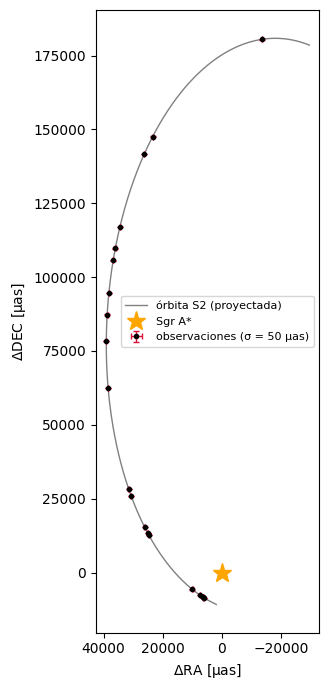

In [23]:
pwe_radec = PathWithErrorRADEC(
    path,
    sigma_radec_uas=50.0,
    zeta=0.0, eta=0.0,
    distance=dist_pc * u.pc, mass=M_SgrA,
    sigma_t=err_time, N_points=20, seed=42,
)

sigma_uas = pwe_radec.sigma_radec_uas

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(pwe_radec.ra_path * DEG2UAS, pwe_radec.dec_path * DEG2UAS,
        "-", lw=1.0, color="gray", label="órbita S2 (proyectada)")
ax.errorbar(
    pwe_radec.ra_obs * DEG2UAS, pwe_radec.dec_obs * DEG2UAS,
    xerr=sigma_uas, yerr=sigma_uas,
    fmt="o", ms=3, color="black", ecolor="crimson",
    elinewidth=1.0, capsize=2, label=f"observaciones (σ = {sigma_uas:.0f} µas)",
)
ax.plot(0, 0, "*", ms=14, color="orange", label="Sgr A*")
ax.invert_xaxis()  # este a la izquierda (convención astronómica)
ax.set_xlabel(r"$\Delta$RA [µas]")
ax.set_ylabel(r"$\Delta$DEC [µas]")
ax.set_aspect("equal")
ax.legend(fontsize=8)
plt.tight_layout()

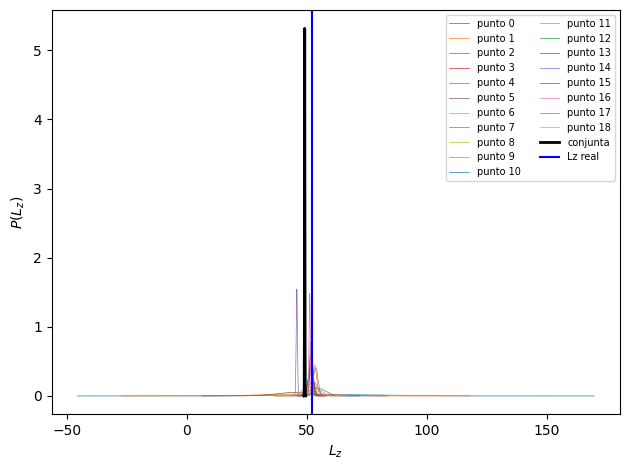

In [24]:
# Distribuciones de Lz (S2) — mismas funciones de la sección cartesiana
N_pts = len(pwe_radec.points_mid[0])
dists = [_get_lz_dist(pwe_radec, i) for i in range(N_pts)]
Lz_joint, dist_joint = joint_lz(pwe_radec)

fig, ax = plt.subplots()
for i, (Lzs, dist_Lz) in enumerate(dists):
    ax.plot(Lzs, dist_Lz, "-", lw=0.5, label=f"punto {i}")
ax.plot(Lz_joint, dist_joint, color="black", lw=2.0, label="conjunta")
Lz_real = float(path._get_Lz(kerr).mean())
ax.axvline(Lz_real, color="blue", lw=1.5, label="Lz real")
ax.set_xlabel(r"$L_z$")
ax.set_ylabel(r"$P(L_z)$")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()

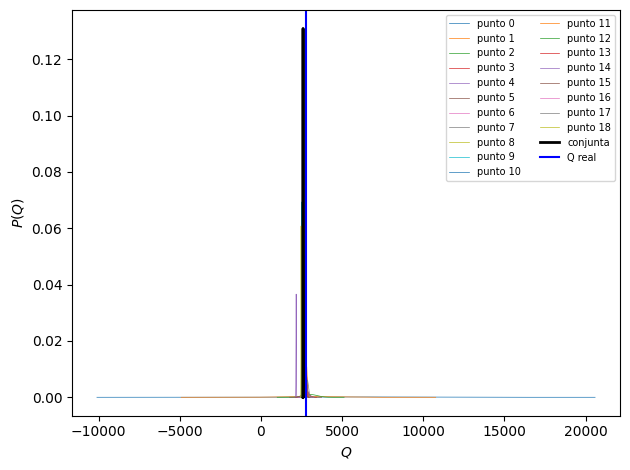

In [25]:
# Distribuciones de Q (S2) — Monte Carlo por punto + conjunta analítica
dists_Q = [_get_q_dist(pwe_radec, i, kerr, N_mc=300, seed=400 + i)
           for i in range(N_pts)]
Q_joint, dist_joint_Q = joint_q(pwe_radec, kerr, N_mc=300)

fig, ax = plt.subplots()
for i, (Qs, dist_Q) in enumerate(dists_Q):
    if Qs.size == 0:
        continue
    ax.plot(Qs, dist_Q, "-", lw=0.5, label=f"punto {i}")
ax.plot(Q_joint, dist_joint_Q, color="black", lw=2.0, label="conjunta")
Q_real = float(path._get_Q(kerr).mean())
ax.axvline(Q_real, color="blue", lw=1.5, label="Q real")
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$P(Q)$")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()

In [26]:
import pandas as pd


def _joint_stats(grid, pdf):
    mu = np.trapezoid(grid * pdf, grid)
    var = np.trapezoid((grid - mu) ** 2 * pdf, grid)
    return mu, np.sqrt(var)


mu_lz, s_lz = _joint_stats(Lz_joint, dist_joint)
mu_q, s_q = _joint_stats(Q_joint, dist_joint_Q)

resumen_radec = pd.DataFrame(
    {
        "mu_joint": [mu_lz, mu_q],
        "sigma_joint": [s_lz, s_q],
        "real": [Lz_real, Q_real],
    },
    index=["Lz", "Q"],
)
resumen_radec["desv_rel"] = (resumen_radec["mu_joint"] - resumen_radec["real"]) / resumen_radec["real"]
resumen_radec["z_score"] = (resumen_radec["mu_joint"] - resumen_radec["real"]) / resumen_radec["sigma_joint"]
resumen_radec

,mu_joint,sigma_joint,real,desv_rel,z_score
Lz,49.073749,0.075029,52.001046,-0.056293,-39.015570
Q,2594.441703,3.046674,2787.092568,-0.069123,-63.233183


# En función del número de puntos

Mismo análisis que en 008 pero con el modelo de error **astrométrico**: el
ruido se inyecta en RA/DEC ($\sigma = 50\,\mu$as) vía `PathWithErrorRADEC`
y se propaga numéricamente (KDE-product) hasta el Z-score del valor real.

In [27]:
# Muestreo numérico por punto.
#
# Razón: en el futuro las distribuciones de error NO serán gaussianas.
# Por eso evitamos toda fórmula cerrada y construimos las distribuciones
# por sampleo directo. Mismo esqueleto que _mc_eq_samples pero exponiendo
# arrays (N_pts, N_mc) para combinar luego en grilla común.

from scipy.stats import gaussian_kde, norm
from scipy.integrate import cumulative_trapezoid


def lz_samples_point(pwe, i, N_mc=500, seed=None):
    """Muestras de Lz = -(x·vy - y·vx) para el punto i."""
    rng = np.random.default_rng(seed)
    x  = rng.normal(pwe.points_mid[0, i],  pwe.point_mid_errors[0, i],  N_mc)
    y  = rng.normal(pwe.points_mid[1, i],  pwe.point_mid_errors[1, i],  N_mc)
    vx = rng.normal(pwe.velocities[0, i],  pwe.velocity_errors[0, i],   N_mc)
    vy = rng.normal(pwe.velocities[1, i],  pwe.velocity_errors[1, i],   N_mc)
    return -(x * vy - y * vx)


def lz_samples_all(pwe, N_mc=500, seed=0):
    N_pts = pwe.points_mid.shape[1]
    return np.stack([lz_samples_point(pwe, i, N_mc, seed + i) for i in range(N_pts)])


def q_samples_all(pwe, kerr, N_mc=500, seed=0):
    """Reusa _mc_eq_samples, devuelve solo Q."""
    N_pts = pwe.points_mid.shape[1]
    out = []
    for i in range(N_pts):
        _, Qs = _mc_eq_samples(pwe, i, kerr, N_mc=N_mc, seed=seed + i)
        out.append(Qs)
    # _mc_eq_samples filtra NaN → tamaños posiblemente desiguales; reducimos
    # al mínimo común para shape (N_pts, N_mc_eff)
    m = min(len(o) for o in out)
    if m < 10:
        raise RuntimeError(f"q_samples_all: muy pocas muestras válidas ({m})")
    return np.stack([o[:m] for o in out])

In [28]:
# Distribución conjunta numérica + Z-score via CDF empírica.
#
# Producto-de-pdfs: cada punto da una medición INDEPENDIENTE de la misma
# cantidad conservada (Lz, Q). Posterior conjunto ∝ ∏ pᵢ. Esto generaliza
# el inverse-variance weighting de joint_lz al caso no-gaussiano.
#
# Implementación:
#   1. KDE por punto sobre grilla común amplia.
#   2. Suma de log-pdfs para evitar underflow.
#   3. Normalización por trapecio → pdf_joint.
#   4. CDF acumulada.
#   5. Z-score: z = Φ⁻¹( F_joint(true) ).


def joint_pdf_numeric(samples_per_point, grid_size=4096, pad_sigmas=6):
    """
    samples_per_point : (N_pts, N_mc)
    Returns (grid, pdf_joint, cdf_joint).
    """
    S = np.asarray(samples_per_point)
    mus    = S.mean(axis=1)
    sigmas = S.std(axis=1, ddof=1)

    lo = (mus - pad_sigmas * sigmas).min()
    hi = (mus + pad_sigmas * sigmas).max()
    grid = np.linspace(lo, hi, grid_size)

    log_joint = np.zeros_like(grid)
    for row in S:
        kde = gaussian_kde(row)
        log_joint += np.log(kde(grid) + 1e-300)

    log_joint -= log_joint.max()
    pdf = np.exp(log_joint)
    Z = np.trapezoid(pdf, grid)
    if not np.isfinite(Z) or Z <= 0:
        raise RuntimeError("joint_pdf_numeric: normalización degenerada (grid demasiado angosto?)")
    pdf /= Z
    cdf = cumulative_trapezoid(pdf, grid, initial=0.0)
    cdf /= cdf[-1]
    return grid, pdf, cdf


def sigma_distance(grid, cdf, true_value):
    """
    Z-score equivalente del valor real en la distribución conjunta.
    Generaliza |x-μ|/σ al caso no-gaussiano vía la CDF empírica.
    Retorna z signed; usar |z| para distancia.
    """
    if true_value < grid[0]:
        F = 1e-12
    elif true_value > grid[-1]:
        F = 1 - 1e-12
    else:
        F = float(np.interp(true_value, grid, cdf))
        F = np.clip(F, 1e-12, 1 - 1e-12)
    return float(norm.ppf(F))

In [29]:
# Sanity check: joint_pdf_numeric debe coincidir con joint_lz (analítico)
# en régimen gaussiano. Diferencias ~ ruido KDE/MC.

Lz_real = float(path._get_Lz(kerr).mean())
S_lz = lz_samples_all(pwe_radec, N_mc=2000, seed=0)
grid_L, pdf_L, cdf_L = joint_pdf_numeric(S_lz)

mu_num    = float(np.trapezoid(grid_L * pdf_L, grid_L))
sigma_num = float(np.sqrt(np.trapezoid((grid_L - mu_num)**2 * pdf_L, grid_L)))

Lz_ana_grid, Lz_ana_pdf = joint_lz(pwe_radec)
mu_ana    = float(np.trapezoid(Lz_ana_grid * Lz_ana_pdf, Lz_ana_grid))
sigma_ana = float(np.sqrt(np.trapezoid((Lz_ana_grid - mu_ana)**2 * Lz_ana_pdf, Lz_ana_grid)))

z_lz = sigma_distance(grid_L, cdf_L, Lz_real)

pd.DataFrame({
    "numeric":  [mu_num, sigma_num, z_lz],
    "analytic": [mu_ana, sigma_ana, (Lz_real - mu_ana) / sigma_ana],
}, index=["mu_joint", "sigma_joint", "z (true vs joint)"])

,numeric,analytic
mu_joint,49.388637,49.073749
sigma_joint,0.028898,0.075029
z (true vs joint),7.034487,39.015570


In [30]:
# Sweep: |z| vs N puntos en una órbita, para Lz y Q — versión RA/DEC.
#
# Por cada (N, seed):
#   - construir PathWithErrorRADEC con N puntos (ruido en el plano del cielo)
#   - muestrear Lz y Q numéricamente
#   - construir conjuntas via KDE-product
#   - calcular Z-score del valor real

from joblib import Parallel, delayed


def _one_run_radec(path, sigma_uas, sigma_t, kerr, N, seed, N_mc,
                   Lz_real, Q_real, zeta, eta, distance, mass):
    try:
        pwe_n = PathWithErrorRADEC(path, sigma_radec_uas=sigma_uas,
                                   zeta=zeta, eta=eta,
                                   distance=distance, mass=mass,
                                   sigma_t=sigma_t, N_points=N, seed=seed)
        S_lz = lz_samples_all(pwe_n, N_mc=N_mc, seed=seed)
        gL, _, cL = joint_pdf_numeric(S_lz)
        z_lz = sigma_distance(gL, cL, Lz_real)

        S_q = q_samples_all(pwe_n, kerr, N_mc=N_mc, seed=seed + 10_000)
        gQ, _, cQ = joint_pdf_numeric(S_q)
        z_q = sigma_distance(gQ, cQ, Q_real)
    except Exception as e:
        return {"N": N, "seed": seed, "z_Lz": np.nan, "z_Q": np.nan, "err": repr(e)}
    return {"N": N, "seed": seed, "z_Lz": z_lz, "z_Q": z_q, "err": ""}


def sweep_n_points_radec(path, sigma_uas, sigma_t, kerr, N_list,
                         n_seeds=10, N_mc=300, n_jobs=-1,
                         zeta=0.0, eta=0.0,
                         distance=dist_pc * u.pc, mass=M_SgrA):
    Lz_real = float(path._get_Lz(kerr).mean())
    Q_real  = float(path._get_Q(kerr).mean())

    jobs = [(N, s) for N in N_list for s in range(n_seeds)]
    rows = Parallel(n_jobs=n_jobs, backend="loky", verbose=5)(
        delayed(_one_run_radec)(path, sigma_uas, sigma_t, kerr,
                                N, s, N_mc, Lz_real, Q_real,
                                zeta, eta, distance, mass)
        for (N, s) in jobs
    )
    return pd.DataFrame(rows)

In [31]:
# Ejecución del sweep — cacheado a disco (computa solo si no existe el pkl).
# N ∈ [2, 500] (PathWithError necesita N≥2 para midpoints).
from pathlib import Path as _Path

CACHE_SWEEP_N = _Path("009_sweep_n_radec.pkl")

N_list  = np.unique(np.round(np.linspace(2, 500, 20)).astype(int))
n_seeds = 10
N_mc    = 300

if CACHE_SWEEP_N.exists():
    df_sweep = pd.read_pickle(CACHE_SWEEP_N)
else:
    df_sweep = sweep_n_points_radec(
        path, sigma_uas=50.0, sigma_t=err_time, kerr=kerr,
        N_list=N_list, n_seeds=n_seeds, N_mc=N_mc, n_jobs=-1,
    )
    df_sweep.to_pickle(CACHE_SWEEP_N)
df_sweep

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.3min finished


,N,seed,z_Lz,z_Q,err
0,2,0,7.034487,7.034487,
1,2,1,-0.606960,2.254575,
2,2,2,7.034487,7.034487,
3,2,3,7.034487,7.034487,
4,2,4,7.034487,7.034487,
...,...,...,...,...,...
195,500,5,-0.319477,-1.370736,
196,500,6,-0.698758,0.118322,
197,500,7,0.980481,-0.649121,
198,500,8,0.145402,0.492977,


In [32]:
# Agregados sobre seeds: mediana + IQR de |z| vs N.

df_abs = df_sweep.assign(
    abs_z_Lz=df_sweep["z_Lz"].abs(),
    abs_z_Q=df_sweep["z_Q"].abs(),
).dropna(subset=["abs_z_Lz", "abs_z_Q"])

agg = (df_abs.groupby("N")
              .agg(med_Lz=("abs_z_Lz", "median"),
                   q1_Lz =("abs_z_Lz", lambda x: x.quantile(0.25)),
                   q3_Lz =("abs_z_Lz", lambda x: x.quantile(0.75)),
                   med_Q =("abs_z_Q",  "median"),
                   q1_Q  =("abs_z_Q",  lambda x: x.quantile(0.25)),
                   q3_Q  =("abs_z_Q",  lambda x: x.quantile(0.75)))
              .reset_index())
agg

,N,med_Lz,q1_Lz,q3_Lz,med_Q,q1_Q,q3_Q
0,2,7.034487,7.034487,7.034487,7.034487,7.034487,7.034487
1,28,7.034487,7.034487,7.034487,7.034487,7.034487,7.034487
2,54,2.710421,1.840838,3.661420,0.746497,0.282504,6.673497
3,81,0.964032,0.444665,1.179197,0.371697,0.281671,0.730514
4,107,0.805915,0.324477,1.024806,0.367301,0.073823,0.534041
5,133,0.480542,0.295424,0.603598,0.349017,0.302674,0.395286
6,159,0.288075,0.141386,0.401963,0.234525,0.126029,0.424800
7,185,0.268702,0.120466,0.479114,0.180422,0.090674,0.259486
8,212,0.200194,0.089350,0.487878,0.274243,0.133959,0.390489
9,238,0.240815,0.081079,0.372918,0.249278,0.048488,0.494179


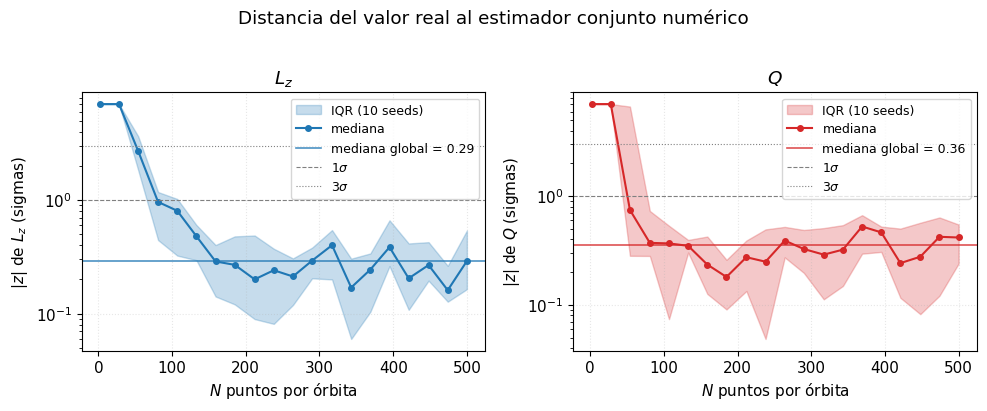

In [33]:
# Gráfica científica: |z| vs N para Lz y Q.

plt.rcParams.update({"font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "grid.linestyle": ":"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

med_overall_Lz = float(np.median(agg["med_Lz"]))
med_overall_Q  = float(np.median(agg["med_Q"]))

for ax, label, med, q1, q3, color, ref in [
    (axes[0], r"$L_z$", agg["med_Lz"], agg["q1_Lz"], agg["q3_Lz"], "C0", med_overall_Lz),
    (axes[1], r"$Q$",   agg["med_Q"],  agg["q1_Q"],  agg["q3_Q"],  "C3", med_overall_Q),
]:
    ax.fill_between(agg["N"], q1, q3, color=color, alpha=0.25,
                    label=f"IQR ({n_seeds} seeds)")
    ax.plot(agg["N"], med, "-o", color=color, ms=4, label="mediana")
    ax.axhline(ref, color=color, ls="-", lw=1.2, alpha=0.8,
               label=f"mediana global = {ref:.2f}")
    ax.axhline(1, color="grey", ls="--", lw=0.8, label=r"$1\sigma$")
    ax.axhline(3, color="grey", ls=":",  lw=0.8, label=r"$3\sigma$")
    ax.set_xlabel(r"$N$ puntos por órbita")
    ax.set_ylabel(rf"$|z|$ de {label} (sigmas)")
    ax.set_title(label)
    ax.legend(fontsize=9, loc="best")
    ax.set_yscale("log")

fig.suptitle("Distancia del valor real al estimador conjunto numérico", y=1.02)
plt.tight_layout()
plt.show()

S2 con errores astrométricos gaussianos de $\sigma = 50\,\mu$as en RA/DEC.

# Mediana entre 10 y 100 puntos a diferentes periodos orbitales. De P/2 a 2P

In [34]:
# Sweep N × P_factor — cacheado a disco (computa solo si no existe el pkl).
# Los paths (kerr, ics_s2, taus=[0, pf*P], Radau2) ya están en PathsBank
# (mismos hashes que 008): no hay reintegración.
CACHE_SWEEP_PF = _Path("009_sweep_pf_radec.pkl")

P_factors = np.round(np.arange(0.5, 2.001, 0.1), 3).tolist()
N_list_pf = np.arange(10, 101, 10)
n_seeds_pf = 10
N_mc_pf    = 300

if CACHE_SWEEP_PF.exists():
    df_period_sweep = pd.read_pickle(CACHE_SWEEP_PF)
else:
    dfs = []
    for pf in P_factors:
        path_pf = bank.get_path(
            kerr, ics_s2, np.array([0.0, pf * P]),
            integrator="Radau2",
        )
        df_pf = sweep_n_points_radec(
            path_pf, sigma_uas=50.0, sigma_t=err_time, kerr=kerr,
            N_list=N_list_pf, n_seeds=n_seeds_pf, N_mc=N_mc_pf, n_jobs=-1,
        )
        df_pf["P_factor"] = pf
        dfs.append(df_pf)
    df_period_sweep = pd.concat(dfs, ignore_index=True)
    df_period_sweep.to_pickle(CACHE_SWEEP_PF)
df_period_sweep

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   15.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   12.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.8s finished
[Parallel(n_jobs=-1)]: Using backend Lok

,N,seed,z_Lz,z_Q,err,P_factor
0,10,0,7.034487,7.034487,,0.5
1,10,1,7.034487,7.034487,,0.5
2,10,2,7.034487,2.434765,,0.5
3,10,3,3.161731,7.034487,,0.5
4,10,4,7.034487,7.034487,,0.5
...,...,...,...,...,...,...
1595,100,5,7.034487,0.125041,,2.0
1596,100,6,7.034487,7.034487,,2.0
1597,100,7,2.492126,0.014971,,2.0
1598,100,8,7.034487,7.034487,,2.0


In [35]:
# Mediana global de |z| sobre seeds por (P_factor, N).
df_period_sweep["abs_z_Lz"] = df_period_sweep["z_Lz"].abs()
df_period_sweep["abs_z_Q"]  = df_period_sweep["z_Q"].abs()

agg_pf = (
    df_period_sweep
    .groupby(["P_factor", "N"])
    .agg(med_Lz=("abs_z_Lz", "median"),
         med_Q =("abs_z_Q",  "median"))
    .reset_index()
)
agg_pf

,P_factor,N,med_Lz,med_Q
0,0.5,10,7.034487,7.034487
1,0.5,20,7.034487,7.034487
2,0.5,30,7.034487,7.034487
3,0.5,40,7.034487,7.034487
4,0.5,50,2.740109,5.973297
...,...,...,...,...
155,2.0,60,7.034487,7.034487
156,2.0,70,7.034487,7.034487
157,2.0,80,7.034487,7.034487
158,2.0,90,7.034487,7.034487


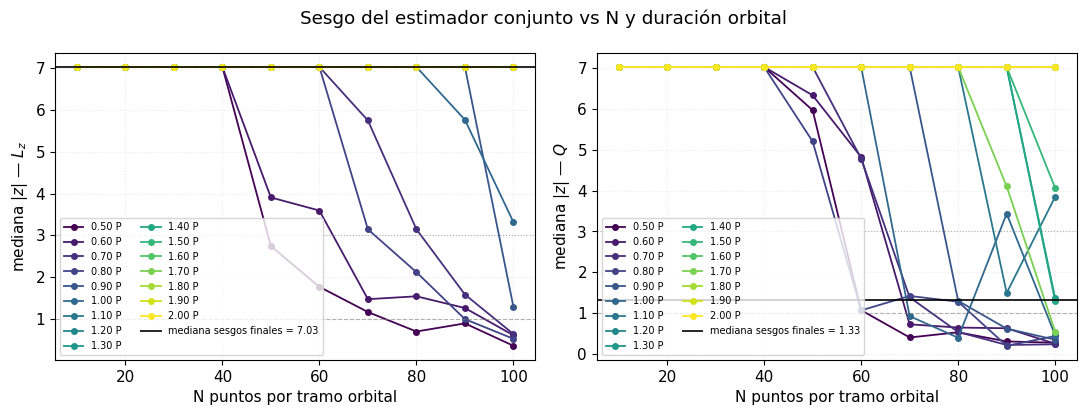

In [36]:
# |z| mediano vs N, una línea por P_factor. Paneles Lz y Q.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
cmap = plt.cm.viridis
pfs = sorted(agg_pf["P_factor"].unique())
colors = {pf: cmap(i / max(len(pfs) - 1, 1)) for i, pf in enumerate(pfs)}

N_final = agg_pf["N"].max()
final_vals_Lz = agg_pf[agg_pf["N"] == N_final]["med_Lz"].values
final_vals_Q  = agg_pf[agg_pf["N"] == N_final]["med_Q"].values
med_final_Lz = float(np.median(final_vals_Lz))
med_final_Q  = float(np.median(final_vals_Q))

for ax, col, ylabel, med_final in [
    (axes[0], "med_Lz", r"mediana $|z|$ — $L_z$", med_final_Lz),
    (axes[1], "med_Q",  r"mediana $|z|$ — $Q$",  med_final_Q),
]:
    for pf in pfs:
        sub = agg_pf[agg_pf["P_factor"] == pf].sort_values("N")
        ax.plot(sub["N"], sub[col], "o-", color=colors[pf],
                lw=1.3, ms=4, label=f"{pf:.2f} P")
    ax.axhline(1.0, color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.axhline(3.0, color="gray", ls=":",  lw=0.8, alpha=0.6)
    ax.axhline(med_final, color="black", ls="-", lw=1.4, alpha=0.85,
               label=f"mediana sesgos finales = {med_final:.2f}")
    ax.set_xlabel("N puntos por tramo orbital")
    ax.set_ylabel(ylabel)
    # ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=7, loc="best", ncol=2)

fig.suptitle("Sesgo del estimador conjunto vs N y duración orbital")
fig.tight_layout()
plt.show()

# Sesgo considerando diferentes condiciones iniciales (RA/DEC)

Mismo análisis que 008 pero con ruido astrométrico ($\sigma = 50\,\mu$as).
Reusa las **5868 órbitas ya integradas** en `paths_bank_ic_sweep` (cache hit
por SHA-256, cero reintegraciones) — solo se recalcula el estimador con el
nuevo modelo de error.

In [37]:
# Sesgo vs IC (RA/DEC) — mismo runner de 008 con --noise radec.
#
# Reusa paths_bank_ic_sweep (5868 paths cacheados): cada job solo corre el
# estimador Monte Carlo (~42 s/job → ~12 h los 1000 en background).
# Lanzar desde Terminal:
#
#   cd <repo_root>
#   mkdir -p bias_ic_radec_results
#   caffeinate -i -s nohup python scripts/008_ic_bias_sweep.py --noise radec \
#       > bias_ic_radec_results/run.log 2>&1 &
#   disown
#
# Monitor:    tail -f bias_ic_radec_results/run.log
# Resume:     re-lanzar el mismo comando; salta los JSON ya existentes.
# Smoke test: python scripts/008_ic_bias_sweep.py --noise radec --limit 3

Independientes: {'spin': 1, 'a': 0, 'e': 0, 'inc': 0}
Conjuntos:     {'spin-a': 0, 'spin-e': 0, 'spin-i': 0, 'a-e': 0, 'a-i': 0, 'e-i': 0}


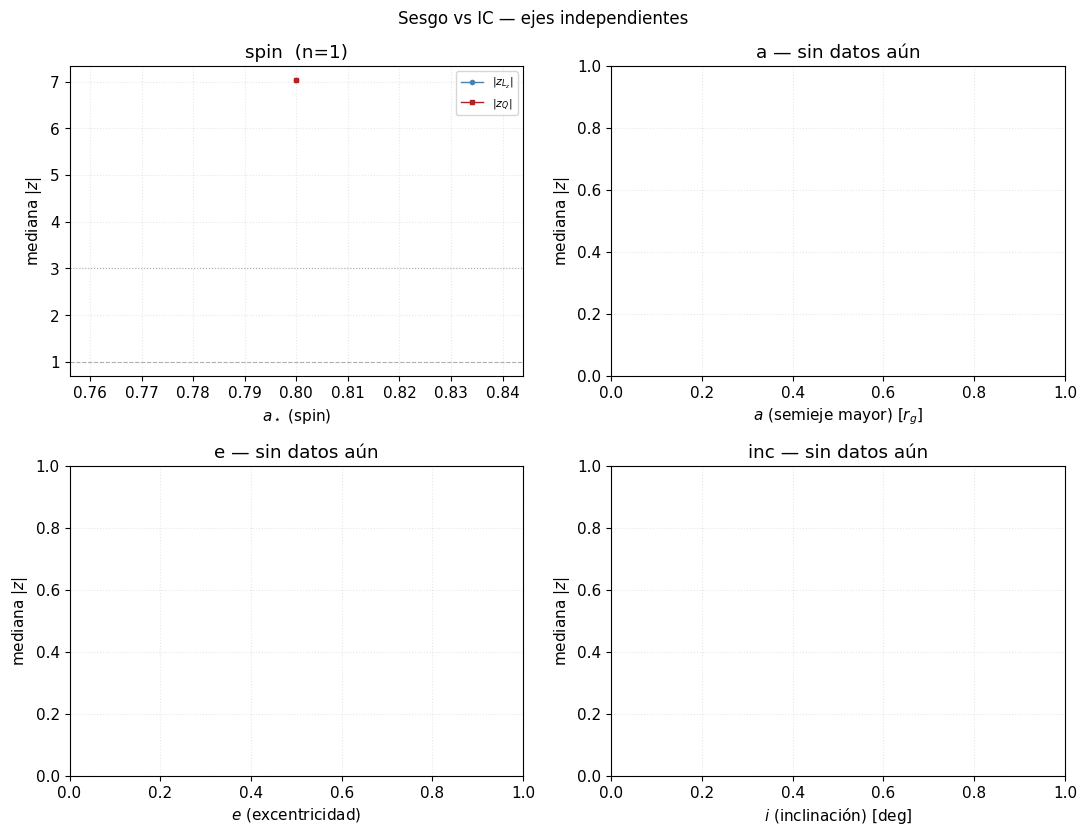

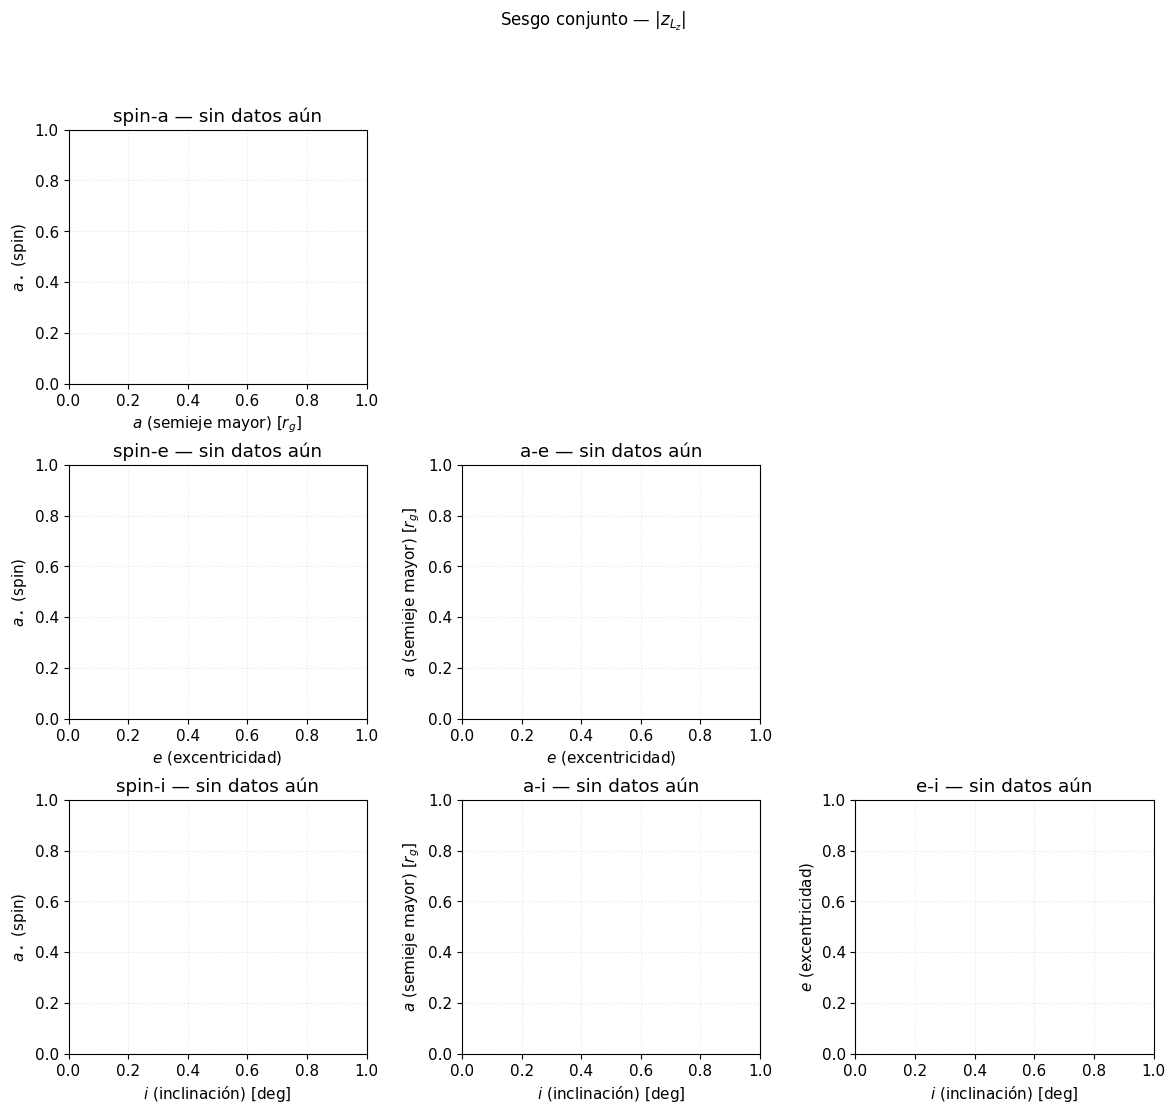

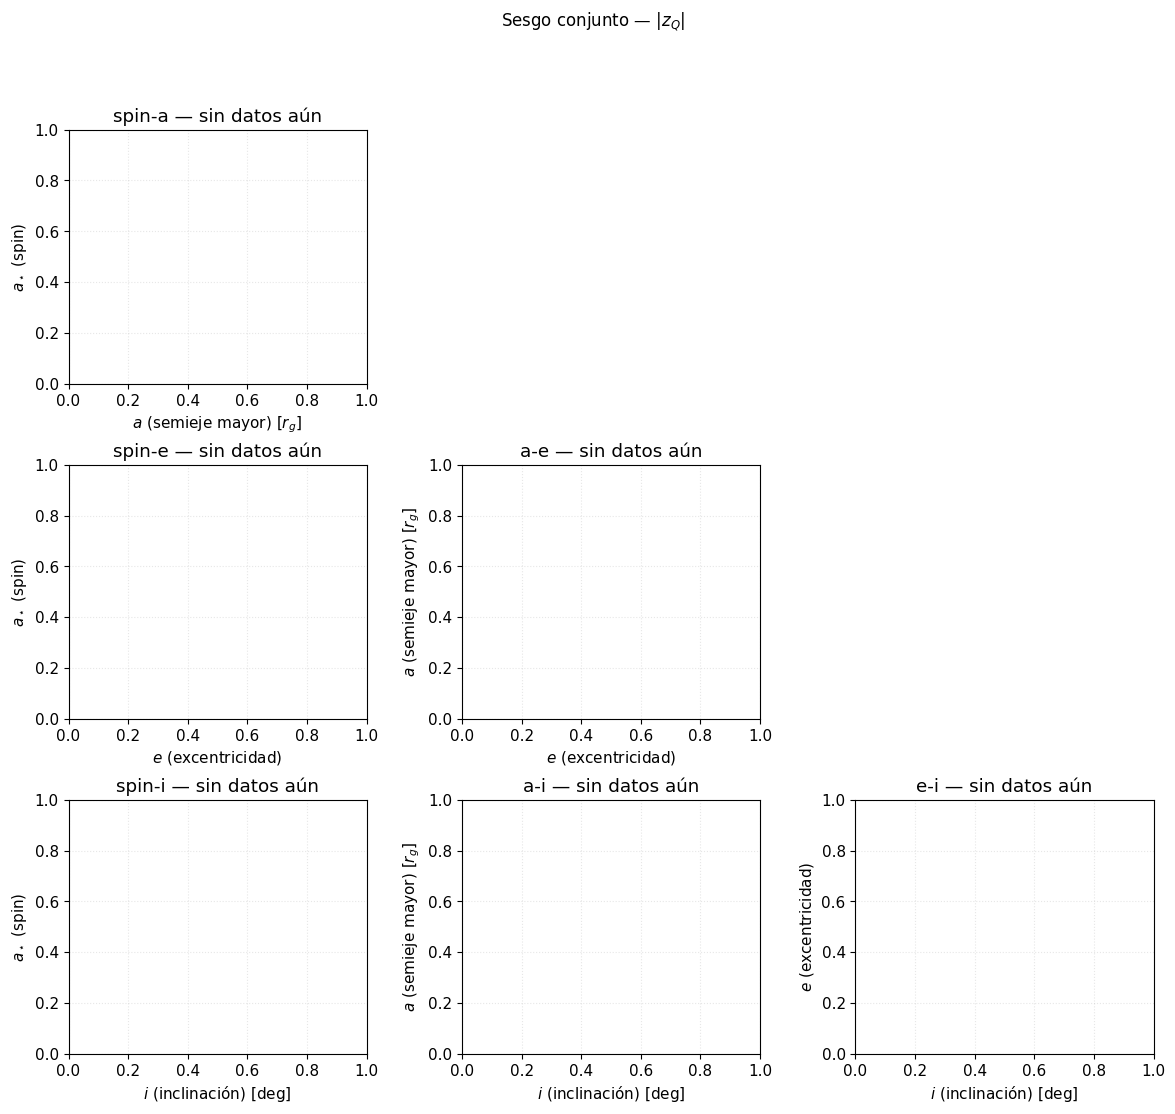

In [40]:
# Cargar y visualizar (re-ejecutable; refresca con lo que haya en disco).
import sys
from pathlib import Path
# Asegurar import de scripts/ desde notebooks/.
_repo = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_repo / "scripts"))

from _bias_lib import load_all_results, plot_independent, plot_joint

res_radec = load_all_results(_repo / "bias_ic_radec_results")
print("Independientes:", {k: len(v) for k, v in res_radec["indep"].items()})
print("Conjuntos:    ", {k: len(v) for k, v in res_radec["pair"].items()})

fig_indep = plot_independent(res_radec, metric="both")
fig_joint_lz = plot_joint(res_radec, metric="lz")
fig_joint_q  = plot_joint(res_radec, metric="q")